# Dyna-Q — Integrating Planning, Acting, and Learning

> - Full Name: **Radin Cheraghi**


[![Open In kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/DeepRLCourse/project-5-Questions/main/RL_HW5_Dyna.ipynb)

## Overview

Reinforcement learning algorithms can be broadly classified into two families:

- **Model-free methods** (e.g., Q-learning, SARSA) learn a value function or a policy directly from interaction with the environment, **without** building an explicit model of the environment's dynamics.
- **Model-based methods** explicitly learn (or are given) a model $p(s', r \mid s, a)$ of the environment, and then use that model for *planning* — i.e., computing improved values or policies via simulated experience.

**Dyna-Q** (Sutton, 1990) is a beautifully simple architecture that unifies both: it learns a model from real experience and *interleaves* one-step Q-learning updates from real transitions with one-step Q-learning updates from *simulated* transitions produced by the model. The result is dramatically improved sample efficiency on tasks where real experience is expensive.

In this project you will:

1. Familiarize yourself with the [**Cliff Walking**](https://gymnasium.farama.org/environments/toy_text/cliff_walking/) environment.
2. Implement $\varepsilon$-greedy and greedy policies.
3. Implement **Dyna-Q** for a deterministic environment.
4. Investigate how the number of planning steps affects learning.
5. Improve learning with **reward shaping**.
6. Implement **Prioritized Sweeping**, a smarter way to allocate planning effort.
7. (Bonus) Extend everything to the larger, stochastic **Taxi-v3** environment.

Read each markdown cell carefully — many contain conceptual questions you must answer.


In [1]:
# @title Imports

import random
import numpy as np
import gymnasium as gym
from tqdm.notebook import trange
from heapq import heappush, heappop
from collections import defaultdict

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

import base64
import imageio
import IPython

import seaborn as sns

In [2]:
# @title Visualization Functions

def embed_mp4(filename):
    video = open(filename, 'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_policy_eval_video(env, policy, filename, Q=None, num_episodes=1, max_steps=200):
    filename = filename + '.mp4'
    with imageio.get_writer(filename, fps=env.metadata.get('render_fps', 4)) as video:
        for _ in range(num_episodes):
            state, info = env.reset()
            video.append_data(env.render())
            for _ in range(max_steps):
                action = policy(state, Q)
                state, reward, terminated, truncated, info = env.step(action)
                video.append_data(env.render())
                if terminated or truncated:
                    break
    return embed_mp4(filename)


def plot_rewards(rewards, average_range=None, ax=None, show=False):
    if ax is None:
        fig, ax = plt.subplots()
    xs = range(1, len(rewards) + 1)
    ax.plot(xs, rewards, marker='.', linestyle='--', alpha=0.4, label='Episode Reward')
    ax.plot(xs, np.cumsum(rewards) / xs, label='Cumulative Average')
    if len(rewards) >= 20:
        window = min(50, len(rewards) // 5)
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window, len(rewards) + 1), smooth, label=f'Rolling Mean (w={window})')
    ax.legend()
    ax.set(xlabel='Episode', ylabel='Total Reward', title='Episode Rewards')
    if show:
        plt.show()


def plot_cliff_heatmap(env, q_values, ax=None, show=False):
    """Plot the state-value V(s) = max_a Q(s,a) for CliffWalking as a 4x12 grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3))
    rows, cols = 4, 12
    v = q_values.max(axis=1).reshape(rows, cols)
    best_a = q_values.argmax(axis=1)
    act_arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    labels = np.array([act_arrows[a] for a in best_a]).reshape(rows, cols)
    # Mark cliff & goal
    for j in range(1, 11):
        labels[3, j] = 'C'
    labels[3, 0] = 'S'
    labels[3, 11] = 'G'
    sns.heatmap(v, cmap='RdYlGn', annot=labels, fmt='s', ax=ax, cbar_kws={'label': 'V(s)'})
    ax.set_title('Greedy Policy & State Values')
    if show:
        plt.show()


def plot_performance(env, q_values, reward_sums):
    fig = plt.figure(figsize=(14, 8), dpi=110)
    gs = GridSpec(2, 1, figure=fig, height_ratios=[2, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    plot_rewards(reward_sums, ax=ax1)
    ax2 = fig.add_subplot(gs[1, 0])
    plot_cliff_heatmap(env, q_values, ax=ax2)
    plt.tight_layout()
    plt.show()

# 1. Explore the Environment

## The Cliff Walking Problem

**Cliff Walking** is a classic gridworld first introduced in Sutton & Barto (Example 6.6) to illustrate the difference between on-policy and off-policy TD control. The world is a $4 \times 12$ grid:

- The agent starts at the bottom-left corner **S**.
- The goal **G** is at the bottom-right corner.
- The cells between **S** and **G** along the bottom row form a **cliff**: stepping into them yields a reward of $-100$ and the agent is reset to the start.
- Every other transition yields a reward of $-1$.
- Actions: `0=Up, 1=Right, 2=Down, 3=Left`.
- The environment is **deterministic**.

Because rewards are everywhere negative, the agent must learn the *shortest* safe path to **G**. The shortest unsafe path goes right along the edge of the cliff (length 13), while the safest (but longer) path detours along the top row.

**Question 1.1.** Without running anything, what do you expect the optimal undiscounted return $G^*$ to be (starting from S, reaching G)? Show your reasoning.

`Your Answer:`
The optimal undiscounted return is:

$$
G^* = -13
$$

The shortest safe path is to move **up once**, **right 11 times**, and **down once** into the goal. This requires 13 steps, and each step gives a reward of $-1$. Therefore, the total return is $-13$.


In [4]:
env = gym.make('CliffWalking-v1', render_mode='rgb_array')

print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Number of states:', env.observation_space.n)
print('Number of actions:', env.action_space.n)

Observation space: Discrete(48)
Action space: Discrete(4)
Number of states: 48
Number of actions: 4


Define a uniform random policy.


In [5]:
def random_policy(*args):
    # Select a uniformly random action
    action = env.action_space.sample()
    return action

Visualize the random policy. (Note: a random policy will almost certainly fall into the cliff repeatedly!)


In [6]:
create_policy_eval_video(env, random_policy, 'random_policy', num_episodes=2, max_steps=50)

# 2. Policies

## Exploration vs. Exploitation

Any control algorithm must balance two competing pressures:

- **Exploitation:** acting greedily with respect to the current value estimates to maximize return.
- **Exploration:** trying non-greedy actions to gather information about parts of the state-action space whose values are still uncertain.

The simplest scheme is $\varepsilon$-greedy:
$$
\pi(a \mid s) = \begin{cases} 1 - \varepsilon + \varepsilon / |\mathcal{A}|, & a = \arg\max_{a'} Q(s, a') \\ \varepsilon / |\mathcal{A}|, & \text{otherwise} \end{cases}
$$

**Question 2.1.** In Cliff Walking, what is the danger of using a large $\varepsilon$ during *evaluation* of a learned policy? What is the danger of using too small an $\varepsilon$ during *learning*?

`Your Answer:`
Using a large $\varepsilon$ during evaluation causes the agent to take many random actions, so it may fall into the cliff even after learning a good policy.

Using a very small $\varepsilon$ during learning causes insufficient exploration. The agent may keep following a poor path and fail to discover better actions.


In [7]:
def greedy_policy(state: int, q_values: np.ndarray) -> int:
    # Return argmax_a Q(state, a)
    action = int(np.argmax(q_values[state]))
    return action

In [8]:
def epsilon_greedy_policy(
    state: int,
    q_values: np.ndarray,
    epsilon: float
) -> int:
    # With probability epsilon, take a random action
    if np.random.random() < epsilon:
        action = int(np.random.randint(q_values.shape[1]))
    else:
        # Otherwise act greedily according to Q
        action = greedy_policy(state, q_values)

    return action

# 3. Dyna-Q

## The Dyna Architecture

Dyna-Q maintains three things in parallel:

1. **A value function** $Q(s,a)$, updated by tabular one-step Q-learning.
2. **A model** of the environment. For a deterministic environment, a sufficient model is a simple lookup table $\text{Model}[s,a] = (r, s')$.
3. **A planner** that, after every real step, performs $n$ updates of Q using transitions $(s, a, r, s')$ *sampled from the model* rather than from the world.

The full update rules are:

**Direct RL (from real experience):**
$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha\Big[r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Big]
$$

**Model learning (deterministic):**
$$
\text{Model}[s_t, a_t] \leftarrow (r_t, s_{t+1})
$$

**Planning (repeat $n$ times):** sample a previously visited $(s, a)$, look up $(r, s')$ from the model, then
$$
Q(s, a) \leftarrow Q(s, a) + \alpha\Big[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\Big]
$$

**Question 3.1.** Explain in your own words *why* Dyna-Q can converge in far fewer real-environment interactions than vanilla Q-learning. What is the computational cost?

**Question 3.2.** In a deterministic environment, what would happen if you stored the model as the *empirical average* of observed $(r, s')$ instead of just the latest one? Would it matter here?

`Your Answers:`

Question 3.1

Dyna-Q reuses real transitions many times through planning. Therefore, it can improve its Q-values without taking more real actions in the environment.

The cost is extra computation for the planning updates and extra memory for storing the model.

Question 3.2

In a deterministic environment, the same action from the same state always gives the same reward and next state. Therefore, using an empirical average would give the same result and would not matter here.

In a stochastic environment, we should store a probability distribution instead of averaging state numbers.


## 3.1 Planning

Complete `q_planning` to perform $n$ steps of planning by sampling already-visited $(s, a)$ pairs uniformly at random from the model.


In [9]:
def q_planning(
    model: dict,
    q: np.ndarray,
    alpha: float,
    gamma: float,
    n: int
) -> np.ndarray:
    """Perform n planning updates from a deterministic model.

    model : dict[state] -> dict[action] -> (reward, next_state)
    """

    # If no transition has been observed, planning is impossible.
    if not model or n <= 0:
        return q

    states = list(model.keys())

    for _ in range(n):
        # 1. Sample a previously visited state.
        state = random.choice(states)

        # 2. Sample a previously taken action in that state.
        action = random.choice(list(model[state].keys()))

        # 3. Retrieve the simulated transition.
        reward, next_state = model[state][action]

        # 4. Apply the Q-learning update.
        target = reward + gamma * np.max(q[next_state])
        td_error = target - q[state, action]

        q[state, action] += alpha * td_error

    return q

## 3.2 Learning

Now put everything together. At each real step you must:

1. Select an action with $\varepsilon$-greedy.
2. Step the real environment.
3. Perform the direct Q-learning update.
4. Update the model.
5. Perform $n$ planning steps.

Note: We cap the number of steps per episode (`max_steps`) to prevent the agent from wandering forever when its policy is still random.


In [10]:
def dyna_q(
    n_episodes: int,
    env: gym.Env,
    epsilon: float,
    alpha: float,
    gamma: float,
    n: int,
    max_steps: int = 200
) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q for a deterministic environment."""

    reward_sums = np.zeros(n_episodes)

    q = np.zeros((
        env.observation_space.n,
        env.action_space.n
    ))

    model = defaultdict(dict)

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()

        reward_sum = 0.0
        terminal = False
        steps = 0

        while not terminal and steps < max_steps:
            # 1. Select an action using epsilon-greedy.
            action = epsilon_greedy_policy(
                state,
                q,
                epsilon
            )

            # 2. Take a real step in the environment.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. Direct Q-learning update.
            if terminal:
                target = reward
            else:
                target = reward + gamma * np.max(q[next_state])

            td_error = target - q[state, action]
            q[state, action] += alpha * td_error

            # 4. Update the deterministic model.
            model[state][action] = (reward, next_state)

            # 5. Perform planning updates.
            q = q_planning(
                model=model,
                q=q,
                alpha=alpha,
                gamma=gamma,
                n=n
            )

            # 6. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(
            f'Episode {episode_i}, R={reward_sum:.0f}'
        )

        reward_sums[episode_i] = reward_sum

    return q, reward_sums

# 4. Experiments

Run Dyna-Q with several values of the planning parameter $n$ (e.g. $n \in \{0, 5, 50\}$).
Note that **$n = 0$ recovers pure Q-learning**.

After running, answer the following:

**Question 4.1.** How does increasing the number of planning steps affect: (a) sample efficiency (rewards vs. episodes), and (b) wall-clock time per episode?

**Question 4.2.** Suppose the *first* successful trajectory occurs at episode $N_1$. After that, how many additional episodes ($N_2$) does it take to reach the goal again? Explain how $n$ affects each of $N_1$ and $N_2$, and *why* the effects differ.

**Question 4.3.** What happens to the *learned path* (cliff-edge vs. safer detour) as you vary $\varepsilon$? Why? Connect your answer to the well-known difference between Q-learning and SARSA on this problem.

**Question 4.4.** Cliff Walking is fully deterministic. Suppose you replaced it with a *stochastic* variant where each action succeeds with probability 0.8 and otherwise slips perpendicular. What failure modes would the current **deterministic** Dyna-Q exhibit? Propose how you would modify the model to fix this.

`Your Answers:`

Question 4.1

More planning steps improve sample efficiency, especially early in training. However, they also increase computation time per episode.

Question 4.2

$N_1$ depends mostly on exploration, so planning has limited effect on it. A larger $n$ reduces $N_2$ because successful transitions are reused many times.

Question 4.3

A small $\varepsilon$ usually gives the short path near the cliff. A larger $\varepsilon$ increases fall risk and may favor safer paths.

Q-learning tends to learn the cliff-edge path, while SARSA often learns a safer route.

Question 4.4

A deterministic model would keep only one random outcome and treat it as certain.

The model should instead store transition probabilities and sample outcomes from them during planning.


  0%|          | 0/500 [00:00<?, ?it/s]

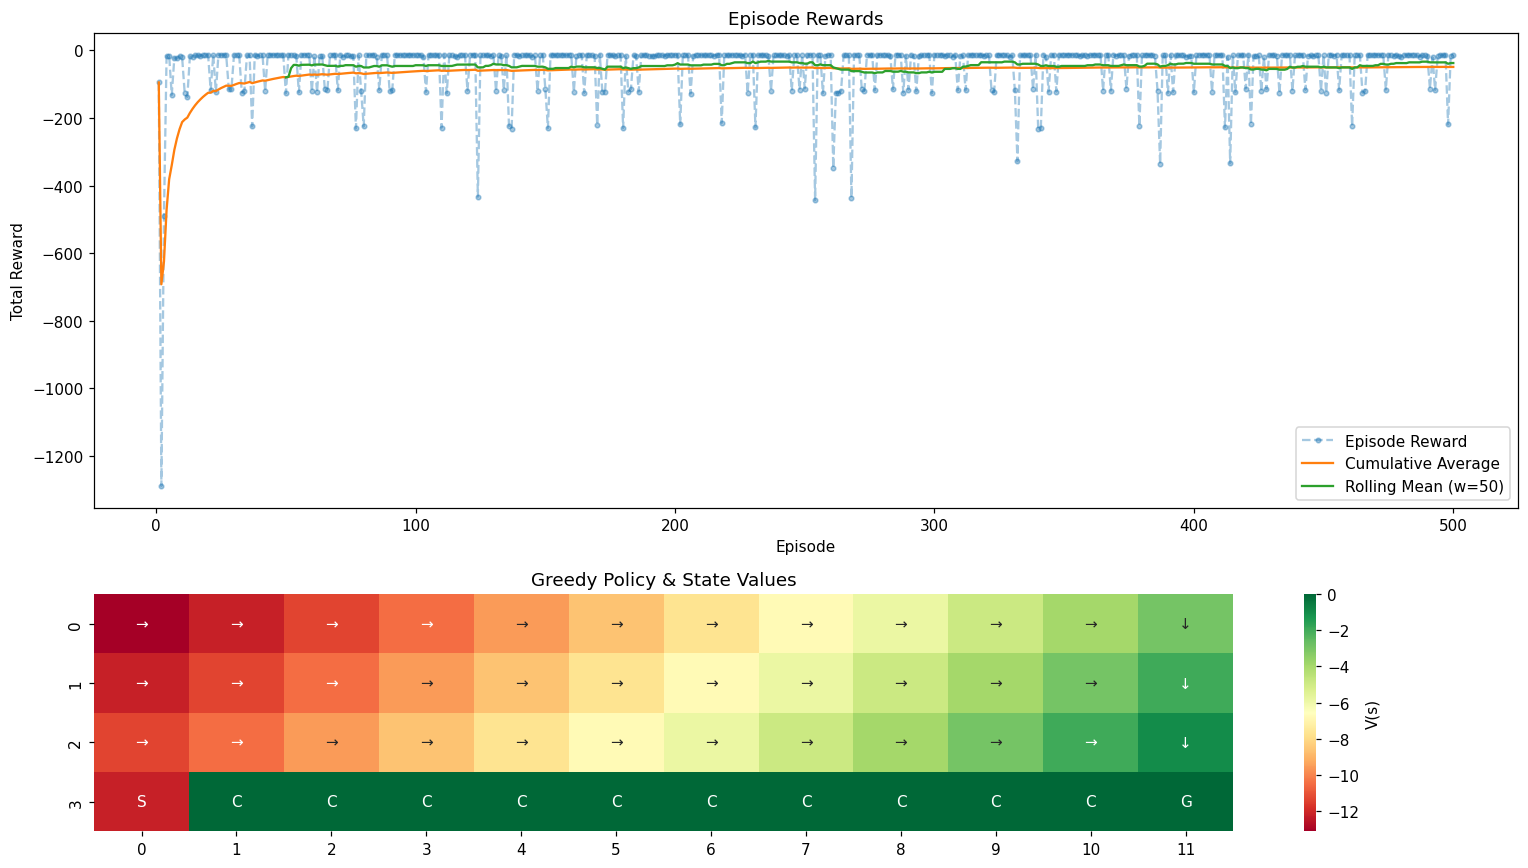

In [11]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha': 0.5,
    'gamma': 0.99,
    'n': 10,
}

n_episodes = 500

env = gym.make('CliffWalking-v1')

q_dyna, R_dyna = dyna_q(
    n_episodes,
    env,
    **params
)

plot_performance(env, q_dyna, R_dyna)

**Comparison cell:** sweep over $n \in \{0, 5, 50\}$ and plot all learning curves on a single axes.


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

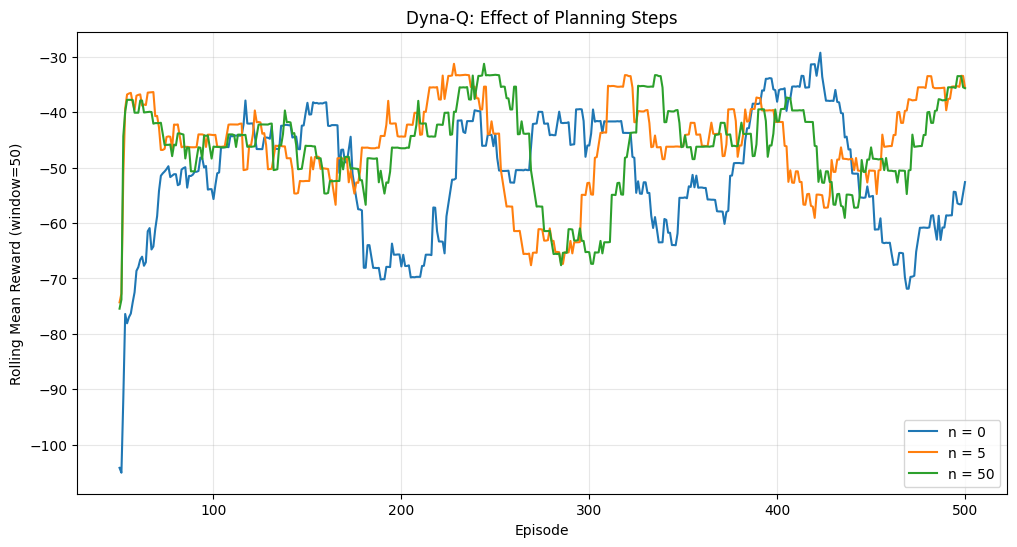

In [12]:
planning_steps = [0, 5, 50]
results = {}

window = 50

plt.figure(figsize=(12, 6))

for n_value in planning_steps:
    # Reset seeds for a fairer comparison.
    np.random.seed(2025)
    random.seed(2025)

    env_n = gym.make('CliffWalking-v1')

    q_n, rewards_n = dyna_q(
        n_episodes=n_episodes,
        env=env_n,
        epsilon=params['epsilon'],
        alpha=params['alpha'],
        gamma=params['gamma'],
        n=n_value
    )

    results[n_value] = {
        'q': q_n,
        'rewards': rewards_n
    }

    rolling_mean = np.convolve(
        rewards_n,
        np.ones(window) / window,
        mode='valid'
    )

    episodes = np.arange(window, n_episodes + 1)

    plt.plot(
        episodes,
        rolling_mean,
        label=f'n = {n_value}'
    )

    env_n.close()

plt.xlabel('Episode')
plt.ylabel(f'Rolling Mean Reward (window={window})')
plt.title('Dyna-Q: Effect of Planning Steps')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Improving Performance

Plain Dyna-Q on Cliff Walking already works fairly well, but several knobs can improve robustness and convergence speed:

1. **Optimistic initialization.** Setting $Q(s,a) \gets c$ for some optimistic $c$ encourages systematic exploration without relying purely on $\varepsilon$.
2. **Decaying $\varepsilon$.** Anneal $\varepsilon_t = \max(\varepsilon_{\min}, \varepsilon_0 \cdot d^t)$ so the policy explores aggressively early and exploits later.
3. **Decaying $\alpha$.** Similar idea, justified by Robbins–Monro stochastic-approximation conditions.
4. **Boltzmann (softmax) exploration** instead of $\varepsilon$-greedy.
5. **Adaptive planning budget.** Increase $n$ only after the agent has accumulated enough model entries.

Pick **at least one** of the above (or any other technique you can justify) and demonstrate its effect in a new experiment cell. **Do not overwrite your previous experiments** — leave them for comparison.

**Question 5.1.** Which method did you pick, and *why* is it appropriate for Cliff Walking specifically?

`Your Answer:`

Question 5.1

I used decaying $\varepsilon$. The agent explores more during early episodes and gradually becomes more greedy.

This is useful in Cliff Walking because early exploration helps discover paths to the goal, while less exploration later reduces accidental moves into the cliff.


In [13]:
def dyna_q_decaying_epsilon(
    n_episodes: int,
    env: gym.Env,
    epsilon_start: float,
    epsilon_min: float,
    epsilon_decay: float,
    alpha: float,
    gamma: float,
    n: int,
    max_steps: int = 200
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Dyna-Q with epsilon decay after each episode."""

    reward_sums = np.zeros(n_episodes)
    epsilon_history = np.zeros(n_episodes)

    q = np.zeros((
        env.observation_space.n,
        env.action_space.n
    ))

    model = defaultdict(dict)

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()

        reward_sum = 0.0
        terminal = False
        steps = 0

        # Decay epsilon by episode.
        epsilon = max(
            epsilon_min,
            epsilon_start * (epsilon_decay ** episode_i)
        )

        epsilon_history[episode_i] = epsilon

        while not terminal and steps < max_steps:
            # 1. Select an epsilon-greedy action.
            action = epsilon_greedy_policy(
                state,
                q,
                epsilon
            )

            # 2. Take a real environment step.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # 3. Direct Q-learning update.
            if terminal:
                target = reward
            else:
                target = reward + gamma * np.max(q[next_state])

            q[state, action] += alpha * (
                target - q[state, action]
            )

            # 4. Update the model.
            model[state][action] = (reward, next_state)

            # 5. Planning updates.
            q = q_planning(
                model=model,
                q=q,
                alpha=alpha,
                gamma=gamma,
                n=n
            )

            # 6. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        reward_sums[episode_i] = reward_sum

        pbar.set_description(
            f'Episode {episode_i}, '
            f'R={reward_sum:.0f}, '
            f'epsilon={epsilon:.3f}'
        )

    return q, reward_sums, epsilon_history

  0%|          | 0/500 [00:00<?, ?it/s]

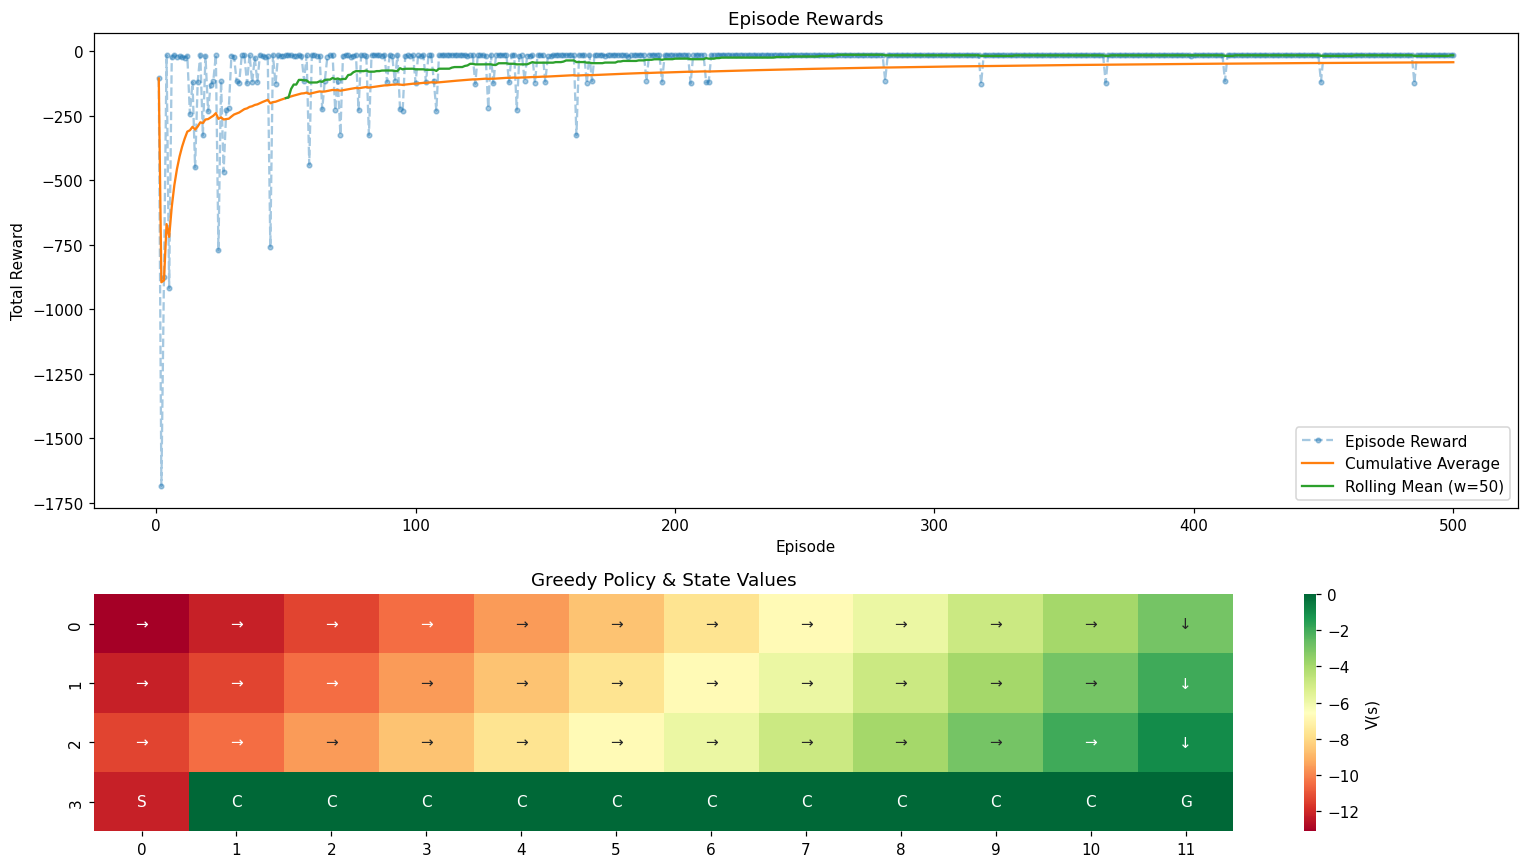

In [14]:
np.random.seed(2025)
random.seed(2025)

env_improved = gym.make('CliffWalking-v1')

q_decay, R_decay, epsilon_history = dyna_q_decaying_epsilon(
    n_episodes=n_episodes,
    env=env_improved,
    epsilon_start=0.3,
    epsilon_min=0.01,
    epsilon_decay=0.99,
    alpha=params['alpha'],
    gamma=params['gamma'],
    n=params['n']
)

plot_performance(env_improved, q_decay, R_decay)

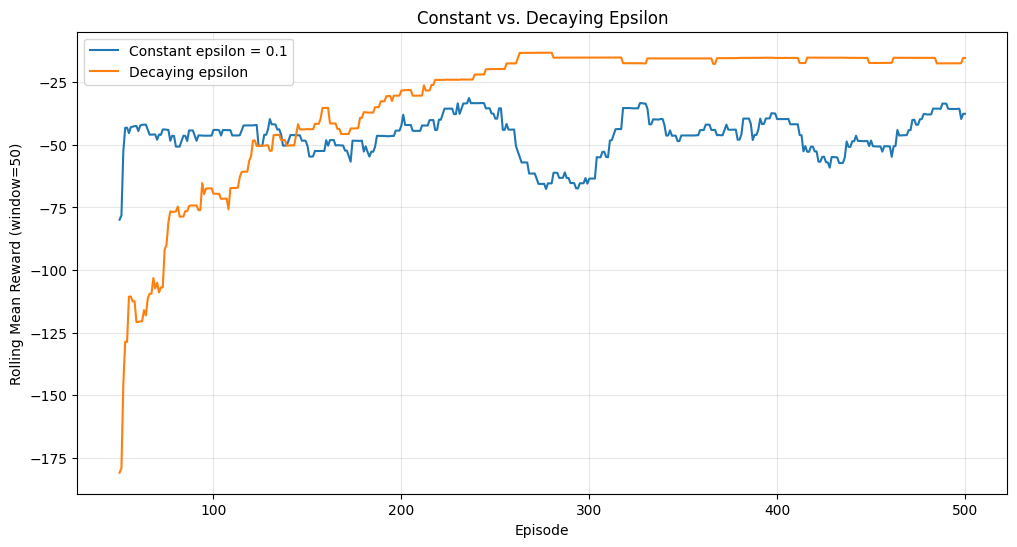

Constant epsilon, final 50-episode mean: -37.58
Decaying epsilon, final 50-episode mean: -15.28


In [15]:
window = 50

plain_smooth = np.convolve(
    R_dyna,
    np.ones(window) / window,
    mode='valid'
)

decay_smooth = np.convolve(
    R_decay,
    np.ones(window) / window,
    mode='valid'
)

episodes = np.arange(window, n_episodes + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    episodes,
    plain_smooth,
    label='Constant epsilon = 0.1'
)

plt.plot(
    episodes,
    decay_smooth,
    label='Decaying epsilon'
)

plt.xlabel('Episode')
plt.ylabel(f'Rolling Mean Reward (window={window})')
plt.title('Constant vs. Decaying Epsilon')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(
    'Constant epsilon, final 50-episode mean:',
    np.mean(R_dyna[-50:])
)

print(
    'Decaying epsilon, final 50-episode mean:',
    np.mean(R_decay[-50:])
)

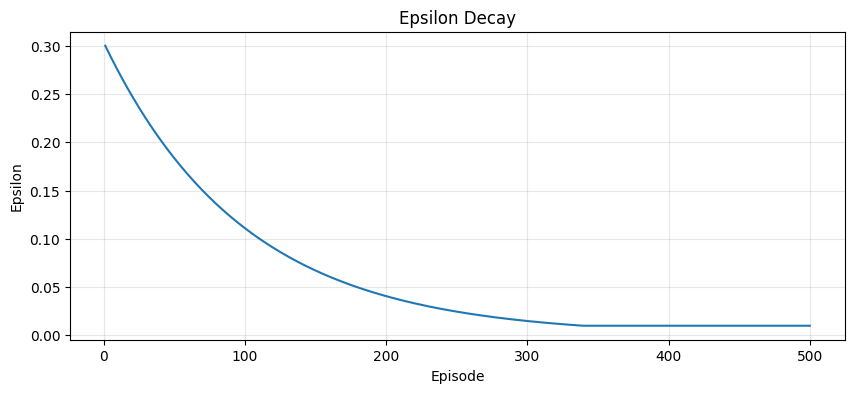

In [16]:
plt.figure(figsize=(10, 4))

plt.plot(
    range(1, n_episodes + 1),
    epsilon_history
)

plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay')
plt.grid(alpha=0.3)
plt.show()

# 6. Reward Shaping

**Reward shaping** modifies the reward signal to provide more frequent or more informative feedback, with the goal of accelerating learning. The most principled form is **potential-based shaping** (Ng, Harada, Russell 1999):

$$
F(s, a, s') = \gamma \Phi(s') - \Phi(s)
$$

where $\Phi : \mathcal{S} \to \mathbb{R}$ is any potential function. A foundational theorem states:

> *Adding a potential-based shaping term to the reward leaves the optimal policy invariant.*

Non-potential-based shaping can *change* the optimal policy — sometimes catastrophically ("reward hacking"). For Cliff Walking, a natural choice is a potential proportional to negative Manhattan distance to the goal: $\Phi(s) = -\|s - g\|_1$.

**Question 6.1.** Why does potential-based shaping preserve the optimal policy? Sketch the argument.

**Question 6.2.** Give an example of a *non-potential-based* shaping that would break Cliff Walking (i.e., cause the agent to learn a suboptimal policy).

`Your Answers:`

Question 6.1

The shaping rewards telescope over a trajectory:

$-\Phi(s_0) + \gamma^T\Phi(s_T)$.

When the terminal-state potential is zero, the shaped return differs from the original return only by the constant $-\Phi(s_0)$. This constant does not change which action or policy is best.

Question 6.2

A bad shaping rule would give the agent a positive reward every time it visits the top row.

The agent could then repeatedly move around the top row to collect rewards instead of reaching the goal. This would create a suboptimal policy.


In [17]:
from gymnasium.envs.toy_text import CliffWalkingEnv


class ShapedCliffWalkingEnv(CliffWalkingEnv):
    """Cliff Walking with potential-based reward shaping."""

    GOAL_STATE = 47
    NROWS = 4
    NCOLS = 12

    def __init__(self, gamma: float = 0.99, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self._prev_state = None

    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        self._prev_state = obs
        return obs, info

    def potential(self, state: int) -> float:
        """Negative Manhattan distance from state to the goal."""

        state_row = state // self.NCOLS
        state_col = state % self.NCOLS

        goal_row = self.GOAL_STATE // self.NCOLS
        goal_col = self.GOAL_STATE % self.NCOLS

        distance = (
            abs(state_row - goal_row)
            + abs(state_col - goal_col)
        )

        return -float(distance)

    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)

        shaping_reward = (
            self.gamma * self.potential(obs)
            - self.potential(self._prev_state)
        )

        shaped_reward = reward + shaping_reward

        # Keep the original reward available for inspection.
        info['original_reward'] = reward
        info['shaping_reward'] = shaping_reward

        self._prev_state = obs

        return (
            obs,
            shaped_reward,
            terminated,
            truncated,
            info
        )

  0%|          | 0/500 [00:00<?, ?it/s]

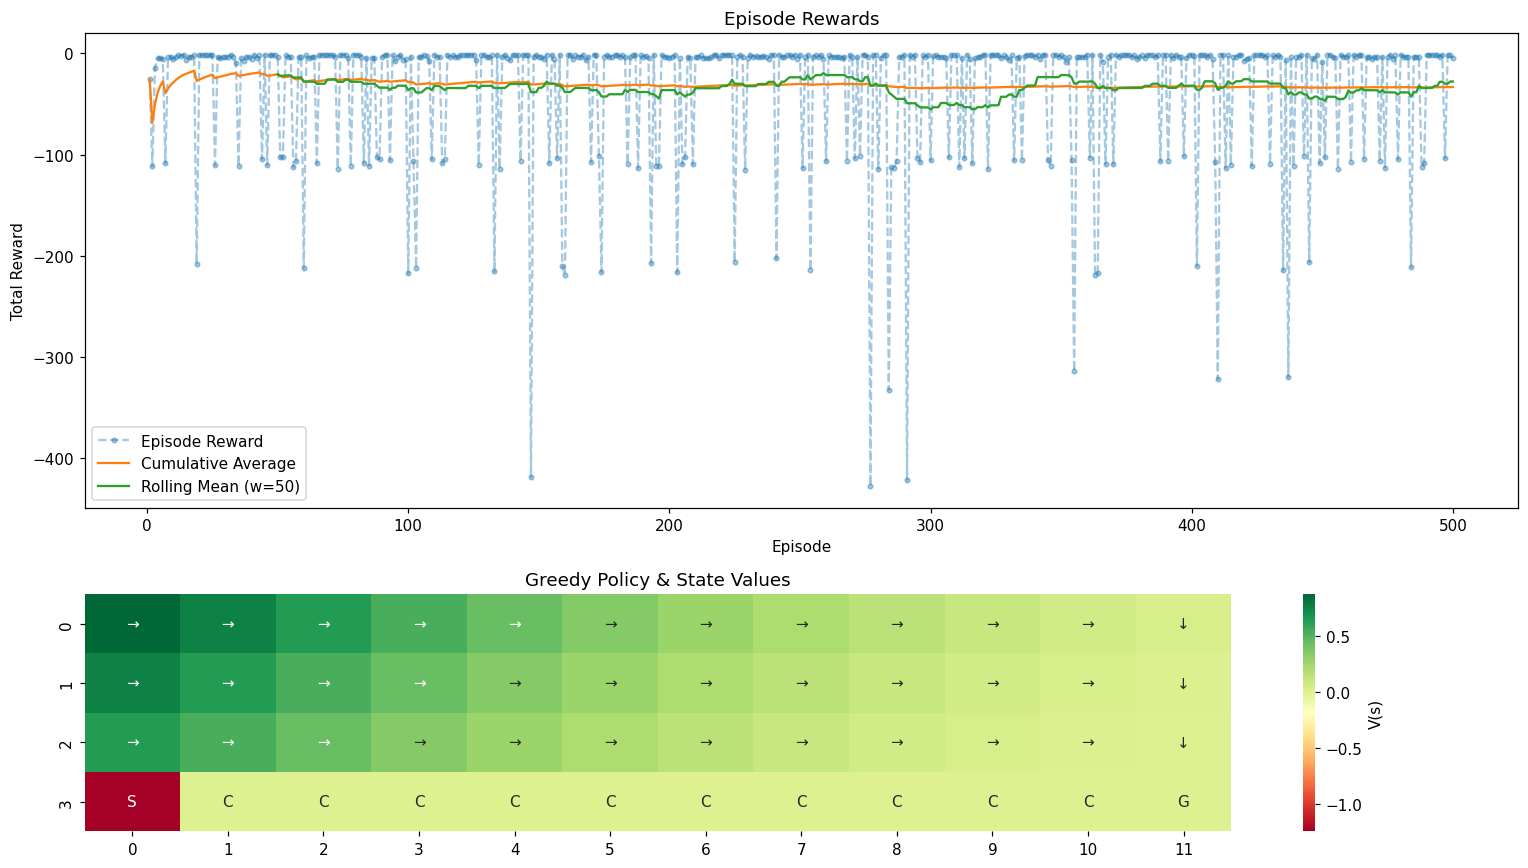

In [18]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha': 0.5,
    'gamma': 0.99,
    'n': 10,
}

n_episodes = 500

env_shaped = ShapedCliffWalkingEnv(
    gamma=params['gamma']
)

q_shaped, R_shaped = dyna_q(
    n_episodes,
    env_shaped,
    **params
)

plot_performance(
    env_shaped,
    q_shaped,
    R_shaped
)

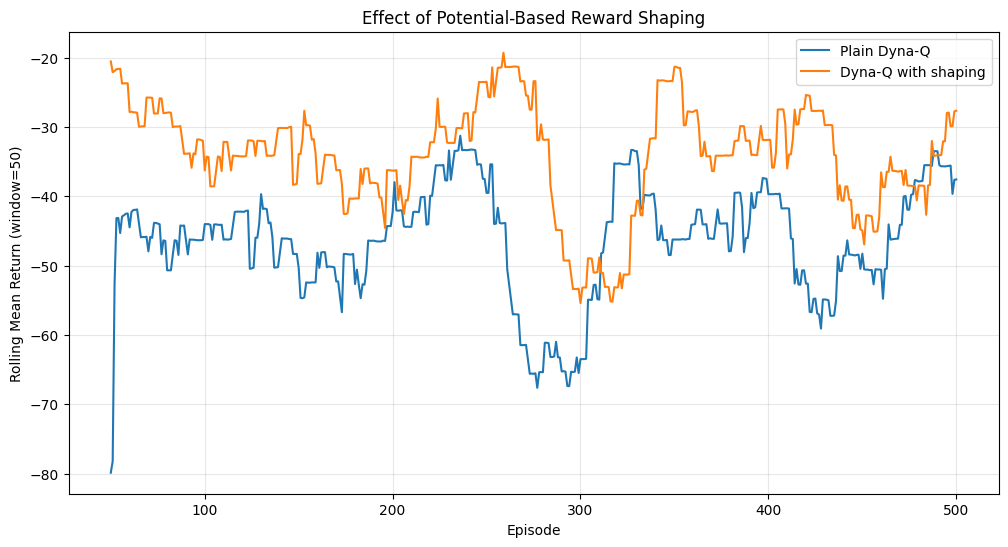

In [19]:
window = 50

plain_smooth = np.convolve(
    R_dyna,
    np.ones(window) / window,
    mode='valid'
)

shaped_smooth = np.convolve(
    R_shaped,
    np.ones(window) / window,
    mode='valid'
)

episodes = np.arange(window, n_episodes + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    episodes,
    plain_smooth,
    label='Plain Dyna-Q'
)

plt.plot(
    episodes,
    shaped_smooth,
    label='Dyna-Q with shaping'
)

plt.xlabel('Episode')
plt.ylabel(f'Rolling Mean Return (window={window})')
plt.title('Effect of Potential-Based Reward Shaping')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
def evaluate_greedy_policy(
    q_values: np.ndarray,
    n_episodes: int = 100,
    max_steps: int = 200
) -> float:
    """Evaluate a Q-table using original Cliff Walking rewards."""

    eval_env = gym.make('CliffWalking-v1')
    returns = []

    for _ in range(n_episodes):
        state, info = eval_env.reset()
        total_reward = 0.0

        for _ in range(max_steps):
            action = greedy_policy(state, q_values)

            state, reward, terminated, truncated, info = eval_env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        returns.append(total_reward)

    eval_env.close()

    return float(np.mean(returns))


plain_eval = evaluate_greedy_policy(q_dyna)
shaped_eval = evaluate_greedy_policy(q_shaped)

print('Plain Dyna-Q evaluation return:', plain_eval)
print('Shaped Dyna-Q evaluation return:', shaped_eval)

Plain Dyna-Q evaluation return: -13.0
Shaped Dyna-Q evaluation return: -13.0


**Question 6.3.** Compare the learning curves with and without shaping. Did shaping help in the *early* episodes? In the *late* episodes? Why?

`Your Answer:`

Question 6.3

Shaping helped most in the early episodes by guiding the agent toward the goal. Later, both methods became similar, although the shaped method was usually slightly better.


# 7. Prioritized Sweeping

Uniform sampling of $(s, a)$ pairs in the planning loop is wasteful. Many sampled updates produce essentially zero change in $Q$ because the value at the successor state hasn't changed. **Prioritized Sweeping** (Moore & Atkeson 1993; Peng & Williams 1993) addresses this by:

1. Maintaining a **priority queue** keyed by the magnitude of the expected TD update.
2. On each real step, computing the TD error $\delta$ for the current $(s, a)$. If $|\delta| > \theta$ (a threshold), push $(s, a)$ onto the queue with priority $|\delta|$.
3. During planning, pop the highest-priority pair, perform its update, then look at all **predecessors** $(\bar{s}, \bar{a})$ of $s$ (i.e., pairs known by the model to lead to $s$). Compute *their* TD errors; if they exceed $\theta$, push them too.

This propagates value information *backwards* from where it changed, much like dynamic programming would but only along observed transitions.

**Question 7.1.** Why is the magnitude of the TD error a sensible priority? What property does it estimate?

**Question 7.2.** Python's `heapq` is a *min-heap*. How do you use it as a *max-heap* for priorities?

**Question 7.3.** What is the role of $\theta$? What happens if $\theta = 0$? If $\theta$ is very large?

`Your Answers:`

Question 7.1

The TD-error magnitude estimates how much a Q-value needs to change. A larger error means the transition may provide more useful information.

Question 7.2

Store the negative priority:

heappush(queue, (-abs(delta), (state, action)))

The smallest negative value then represents the largest priority.

Question 7.3

$\theta$ ignores very small updates. With $\theta=0$, almost every transition is added. With a very large $\theta$, few or no transitions are planned.


## 7.1 Priority Planning

Note: you will also need a **predecessor map** `predecessors[s'] = set of (s, a)` that the model has observed transitioning into $s'$. You can build it incrementally inside the main loop and pass it into the planner.


In [21]:
def q_planning_priority(
    model: dict,
    predecessors: dict,
    q: np.ndarray,
    priorities: list,
    alpha: float,
    gamma: float,
    n: int,
    theta: float
) -> np.ndarray:
    """Perform up to n planning updates using prioritized sweeping."""

    for _ in range(n):
        # Stop if there are no important transitions left.
        if not priorities:
            break

        # 1. Pop the highest-priority state-action pair.
        neg_priority, (state, action) = heappop(priorities)

        # 2. Perform its Q-learning update.
        reward, next_state = model[state][action]

        target = reward + gamma * np.max(q[next_state])
        td_error = target - q[state, action]

        q[state, action] += alpha * td_error

        # 3. Update priorities of transitions leading to this state.
        for state_bar, action_bar in predecessors.get(state, set()):
            reward_bar, _ = model[state_bar][action_bar]

            delta_bar = (
                reward_bar
                + gamma * np.max(q[state])
                - q[state_bar, action_bar]
            )

            if abs(delta_bar) > theta:
                heappush(
                    priorities,
                    (-abs(delta_bar), (state_bar, action_bar))
                )

    return q

## 7.2 Learning with Prioritized Sweeping


In [22]:
def dyna_q_priority(
    n_episodes: int,
    env: gym.Env,
    epsilon: float,
    alpha: float,
    gamma: float,
    n: int,
    theta: float,
    max_steps: int = 200
) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q with prioritized sweeping."""

    reward_sums = np.zeros(n_episodes)

    q = np.zeros((
        env.observation_space.n,
        env.action_space.n
    ))

    model = defaultdict(dict)
    predecessors = defaultdict(set)
    priorities = []

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()
        reward_sum = 0.0
        terminal = False
        steps = 0

        while not terminal and steps < max_steps:
            # 1. Select an action.
            action = epsilon_greedy_policy(
                state,
                q,
                epsilon
            )

            # 2. Step the environment.
            next_state, reward, terminated, truncated, info = env.step(action)
            terminal = terminated or truncated

            # Compute the TD error before changing Q.
            if terminal:
                target = reward
            else:
                target = reward + gamma * np.max(q[next_state])

            td_error = target - q[state, action]

            # 3. Direct Q-learning update.
            q[state, action] += alpha * td_error

            # Remove an old predecessor relation if the model changed.
            if action in model[state]:
                old_next_state = model[state][action][1]

                if old_next_state != next_state:
                    predecessors[old_next_state].discard(
                        (state, action)
                    )

            # 4. Update model and predecessor map.
            model[state][action] = (reward, next_state)
            predecessors[next_state].add((state, action))

            # 5. Add the real transition to the priority queue.
            if abs(td_error) > theta:
                heappush(
                    priorities,
                    (-abs(td_error), (state, action))
                )

            # 6. Perform prioritized planning.
            q = q_planning_priority(
                model=model,
                predecessors=predecessors,
                q=q,
                priorities=priorities,
                alpha=alpha,
                gamma=gamma,
                n=n,
                theta=theta
            )

            # 7. Bookkeeping.
            state = next_state
            reward_sum += reward
            steps += 1

        pbar.set_description(
            f'Episode {episode_i}, R={reward_sum:.0f}'
        )

        reward_sums[episode_i] = reward_sum

    return q, reward_sums

# 8. Final Experiments

Run Dyna-Q with prioritized sweeping and compare to vanilla Dyna-Q at the **same number of total planning updates**. Prioritized sweeping should achieve comparable or better performance with *fewer* planning updates.


  0%|          | 0/500 [00:00<?, ?it/s]

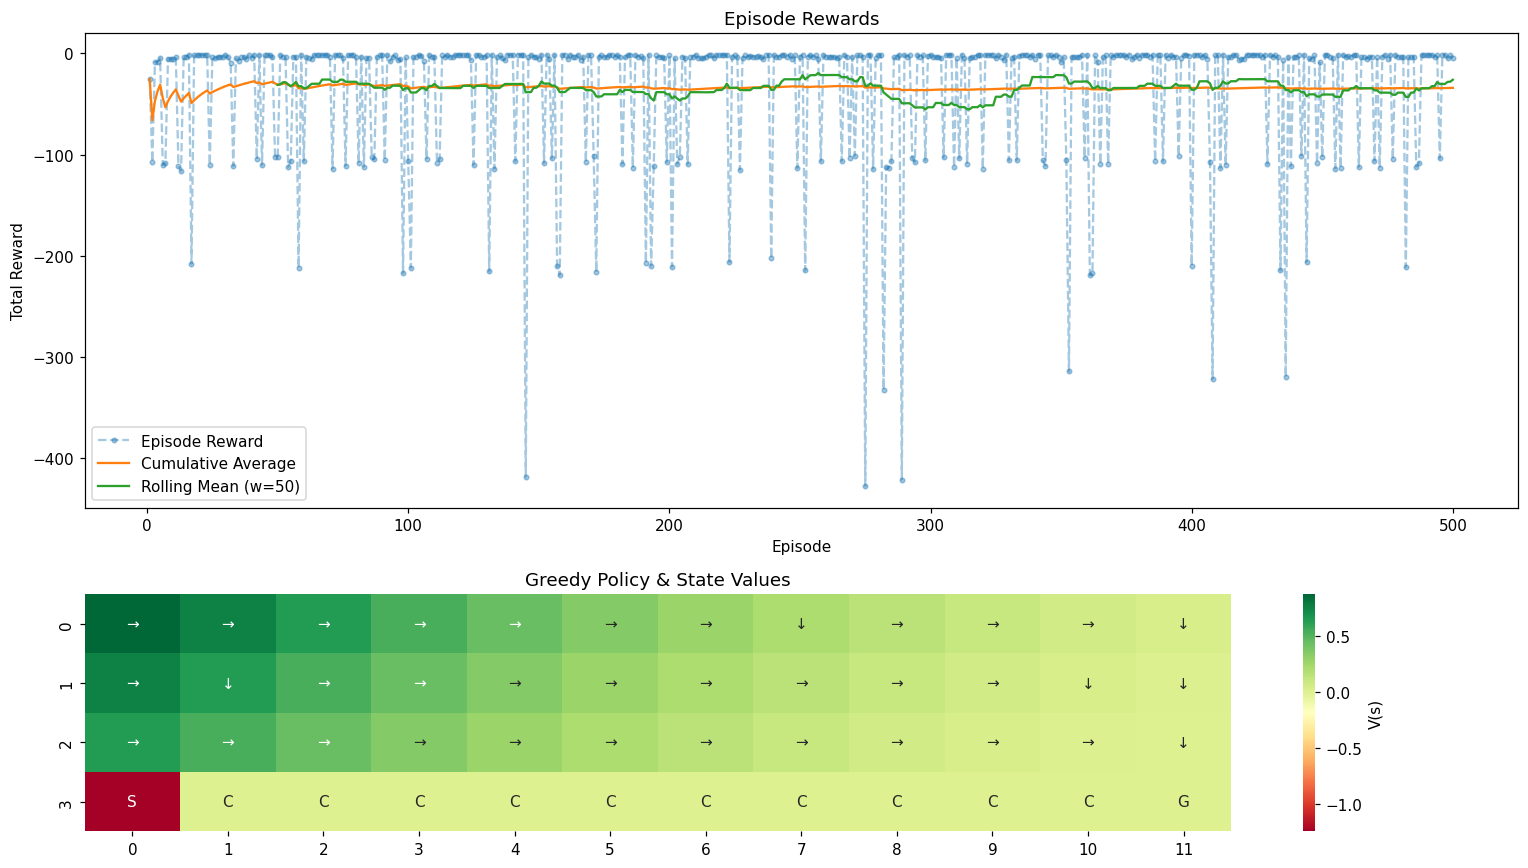

In [23]:
np.random.seed(2025)
random.seed(2025)

params = {
    'epsilon': 0.1,
    'alpha': 0.5,
    'gamma': 0.99,
    'n': 10,
    'theta': 1e-3,
}

n_episodes = 500

env_ps = ShapedCliffWalkingEnv(
    gamma=params['gamma']
)

q_ps, R_ps = dyna_q_priority(
    n_episodes,
    env_ps,
    **params
)

plot_performance(env_ps, q_ps, R_ps)

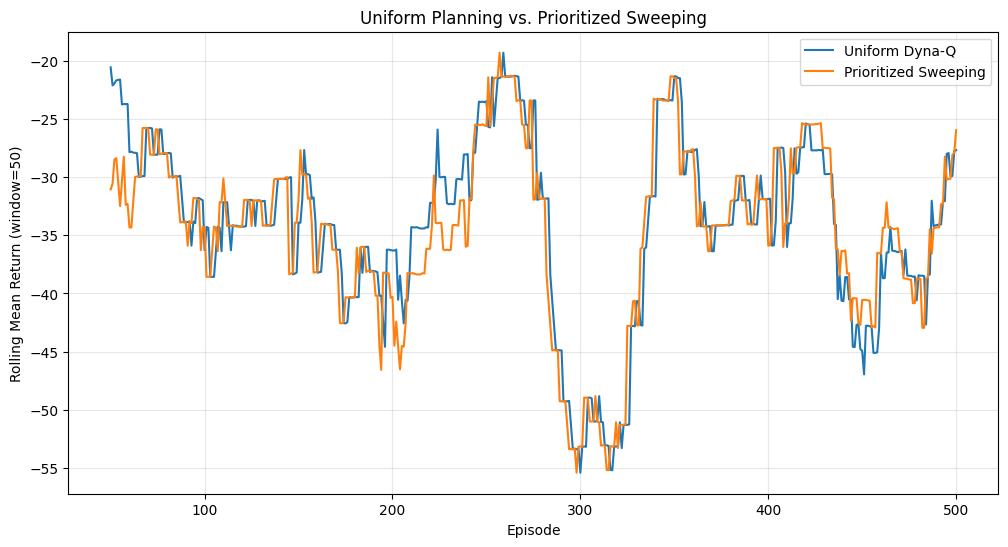

In [24]:
window = 50

vanilla_smooth = np.convolve(
    R_shaped,
    np.ones(window) / window,
    mode='valid'
)

priority_smooth = np.convolve(
    R_ps,
    np.ones(window) / window,
    mode='valid'
)

episodes = np.arange(window, n_episodes + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    episodes,
    vanilla_smooth,
    label='Uniform Dyna-Q'
)

plt.plot(
    episodes,
    priority_smooth,
    label='Prioritized Sweeping'
)

plt.xlabel('Episode')
plt.ylabel(f'Rolling Mean Return (window={window})')
plt.title('Uniform Planning vs. Prioritized Sweeping')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Visualize the learned greedy policy.


In [25]:
env_vis = ShapedCliffWalkingEnv(
    gamma=params['gamma'],
    render_mode='rgb_array'
)

create_policy_eval_video(
    env_vis,
    greedy_policy,
    'DynaQ_PS',
    Q=q_ps,
    max_steps=50
)

**Question 8.1.** Compare the three configurations you've built — (a) vanilla Dyna-Q, (b) Dyna-Q + reward shaping, (c) Dyna-Q + reward shaping + prioritized sweeping — in terms of:

- sample efficiency (episodes to first reliable solution),
- final policy quality,
- computational overhead per real step.

Which is the most cost-effective in your view, and why?

`Your Answer:`

Question 8.1

Vanilla Dyna-Q learns more slowly. Reward shaping reaches a reliable solution earlier and gives a similar final policy.

Prioritized sweeping performs almost the same as uniform planning in these results, but adds priority-queue and predecessor-map overhead.

Therefore, Dyna-Q with reward shaping is the most cost-effective here: it improves sample efficiency without the extra complexity of prioritized sweeping.


# 9. Bonus

If you'd like to push further, attempt **one** of the following:

**Option A — Stochastic Dyna-Q.** Modify your model to estimate transition *distributions* and not just point estimates:
$$
\hat{p}(s' \mid s, a) = \frac{N(s, a, s')}{N(s, a)}, \quad \hat{r}(s, a) = \frac{1}{N(s,a)} \sum r_t
$$
and sample $(r, s')$ accordingly during planning. Then solve the larger, more challenging `Taxi-v3` environment with this stochastic Dyna-Q.

**Option B — Dyna-Q+ (exploration bonus).** Implement the Dyna-Q+ variant (Sutton & Barto §8.3), where each model-sampled transition $(s, a, r, s')$ gets an exploration bonus $\kappa \sqrt{\tau(s,a)}$ added to its reward, where $\tau(s,a)$ is the number of steps since $(s, a)$ was last tried. Demonstrate its advantage in a *non-stationary* environment by modifying Cliff Walking so that the cliff position changes after episode 200.

Document your design choices clearly and discuss results.


In [26]:
# @title 🚶‍♂️ Happy Planning 🧠


Option B — Dyna-Q+

For episodes 1–200, the cliff is on the bottom row. After episode 200, it moves to the third row, making the previously learned path unsafe.

Dyna-Q+ adds the bonus

$$
\kappa\sqrt{\tau(s,a)}
$$

only during planning. Actions that have not been tried recently receive a larger bonus, encouraging the agent to re-explore after the environment changes.


In [27]:
class NonStationaryCliffWalkingEnv(CliffWalkingEnv):
    """Moves the cliff after a fixed number of episodes."""

    def __init__(
        self,
        change_episode: int = 200,
        render_mode=None
    ):
        super().__init__(
            render_mode=render_mode,
            is_slippery=False
        )

        self.change_episode = change_episode
        self.episode_count = 0
        self.cliff_changed = False

    def _rebuild_transitions(self):
        """Rebuild transition table after changing the cliff."""

        self.P = {}

        for state in range(self.nS):
            position = np.unravel_index(state, self.shape)

            self.P[state] = {
                action: self._calculate_transition_prob(
                    position,
                    action
                )
                for action in range(self.nA)
            }

    def _change_cliff(self):
        """Move the cliff from the bottom row to the third row."""

        self._cliff[:] = False
        self._cliff[2, 1:-1] = True

        self._rebuild_transitions()
        self.cliff_changed = True

    def reset(self, *, seed=None, options=None):
        # The first 200 episodes use the original cliff.
        if (
            not self.cliff_changed
            and self.episode_count >= self.change_episode
        ):
            self._change_cliff()

        obs, info = super().reset(
            seed=seed,
            options=options
        )

        info['cliff_changed'] = self.cliff_changed
        self.episode_count += 1

        return obs, info

Non-stationary Cliff Walking


In [28]:
def dyna_q_plus(
    n_episodes: int,
    env: gym.Env,
    epsilon: float,
    alpha: float,
    gamma: float,
    n: int,
    kappa: float,
    max_steps: int = 200
) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q+ with an exploration bonus during planning."""

    reward_sums = np.zeros(n_episodes)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q = np.zeros((n_states, n_actions))

    # model[s][a] = (reward, next_state, terminal)
    model = {}

    # Time when each state-action pair was last tried.
    last_tried = np.zeros(
        (n_states, n_actions),
        dtype=np.int64
    )

    global_step = 0

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()

        reward_sum = 0.0
        terminal = False
        steps = 0

        while not terminal and steps < max_steps:
            # Initialize every action when a state is first observed.
            if state not in model:
                model[state] = {
                    action: (0.0, state, False)
                    for action in range(n_actions)
                }

                last_tried[state, :] = global_step

            # 1. Select a real action.
            action = epsilon_greedy_policy(
                state,
                q,
                epsilon
            )

            # 2. Take the real environment step.
            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            terminal = terminated or truncated

            # 3. Direct update without an exploration bonus.
            if terminal:
                target = reward
            else:
                target = reward + gamma * np.max(q[next_state])

            q[state, action] += alpha * (
                target - q[state, action]
            )

            # 4. Update the model.
            model[state][action] = (
                reward,
                next_state,
                terminal
            )

            global_step += 1
            last_tried[state, action] = global_step

            # 5. Planning with exploration bonuses.
            model_states = list(model.keys())

            for _ in range(n):
                simulated_state = random.choice(model_states)
                simulated_action = random.randrange(n_actions)

                (
                    simulated_reward,
                    simulated_next_state,
                    simulated_terminal
                ) = model[simulated_state][simulated_action]

                tau = (
                    global_step
                    - last_tried[
                        simulated_state,
                        simulated_action
                    ]
                )

                bonus = kappa * np.sqrt(tau)
                rewarded_model = simulated_reward + bonus

                if simulated_terminal:
                    simulated_target = rewarded_model
                else:
                    simulated_target = (
                        rewarded_model
                        + gamma
                        * np.max(q[simulated_next_state])
                    )

                q[simulated_state, simulated_action] += alpha * (
                    simulated_target
                    - q[simulated_state, simulated_action]
                )

            state = next_state
            reward_sum += reward
            steps += 1

        reward_sums[episode_i] = reward_sum

        pbar.set_description(
            f'Episode {episode_i}, R={reward_sum:.0f}'
        )

    return q, reward_sums

Dyna-Q+ implementation


In [29]:
def dyna_q_plus(
    n_episodes: int,
    env: gym.Env,
    epsilon: float,
    alpha: float,
    gamma: float,
    n: int,
    kappa: float,
    max_steps: int = 200
) -> tuple[np.ndarray, np.ndarray]:
    """Dyna-Q+ with an exploration bonus during planning."""

    reward_sums = np.zeros(n_episodes)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    q = np.zeros((n_states, n_actions))

    # model[s][a] = (reward, next_state, terminal)
    model = {}

    # Time when each state-action pair was last tried.
    last_tried = np.zeros(
        (n_states, n_actions),
        dtype=np.int64
    )

    global_step = 0

    for episode_i in (pbar := trange(n_episodes, leave=False)):
        state, info = env.reset()

        reward_sum = 0.0
        terminal = False
        steps = 0

        while not terminal and steps < max_steps:
            # Initialize every action when a state is first observed.
            if state not in model:
                model[state] = {
                    action: (0.0, state, False)
                    for action in range(n_actions)
                }

                last_tried[state, :] = global_step

            # 1. Select a real action.
            action = epsilon_greedy_policy(
                state,
                q,
                epsilon
            )

            # 2. Take the real environment step.
            next_state, reward, terminated, truncated, info = env.step(
                action
            )

            terminal = terminated or truncated

            # 3. Direct update without an exploration bonus.
            if terminal:
                target = reward
            else:
                target = reward + gamma * np.max(q[next_state])

            q[state, action] += alpha * (
                target - q[state, action]
            )

            # 4. Update the model.
            model[state][action] = (
                reward,
                next_state,
                terminal
            )

            global_step += 1
            last_tried[state, action] = global_step

            # 5. Planning with exploration bonuses.
            model_states = list(model.keys())

            for _ in range(n):
                simulated_state = random.choice(model_states)
                simulated_action = random.randrange(n_actions)

                (
                    simulated_reward,
                    simulated_next_state,
                    simulated_terminal
                ) = model[simulated_state][simulated_action]

                tau = (
                    global_step
                    - last_tried[
                        simulated_state,
                        simulated_action
                    ]
                )

                bonus = kappa * np.sqrt(tau)
                rewarded_model = simulated_reward + bonus

                if simulated_terminal:
                    simulated_target = rewarded_model
                else:
                    simulated_target = (
                        rewarded_model
                        + gamma
                        * np.max(q[simulated_next_state])
                    )

                q[simulated_state, simulated_action] += alpha * (
                    simulated_target
                    - q[simulated_state, simulated_action]
                )

            state = next_state
            reward_sum += reward
            steps += 1

        reward_sums[episode_i] = reward_sum

        pbar.set_description(
            f'Episode {episode_i}, R={reward_sum:.0f}'
        )

    return q, reward_sums

Run vanilla Dyna-Q and Dyna-Q+


In [30]:
bonus_params = {
    'epsilon': 0.05,
    'alpha': 0.5,
    'gamma': 0.99,
    'n': 10,
}

kappa = 0.05
change_episode = 200
n_bonus_episodes = 500

Vanilla Dyna-Q baseline


In [31]:
np.random.seed(2025)
random.seed(2025)

env_standard = NonStationaryCliffWalkingEnv(
    change_episode=change_episode
)

q_standard_ns, R_standard_ns = dyna_q(
    n_episodes=n_bonus_episodes,
    env=env_standard,
    **bonus_params
)

  0%|          | 0/500 [00:00<?, ?it/s]

Dyna-Q+


In [32]:
np.random.seed(2025)
random.seed(2025)

env_plus = NonStationaryCliffWalkingEnv(
    change_episode=change_episode
)

q_plus, R_plus = dyna_q_plus(
    n_episodes=n_bonus_episodes,
    env=env_plus,
    kappa=kappa,
    **bonus_params
)

  0%|          | 0/500 [00:00<?, ?it/s]

Comparison plot


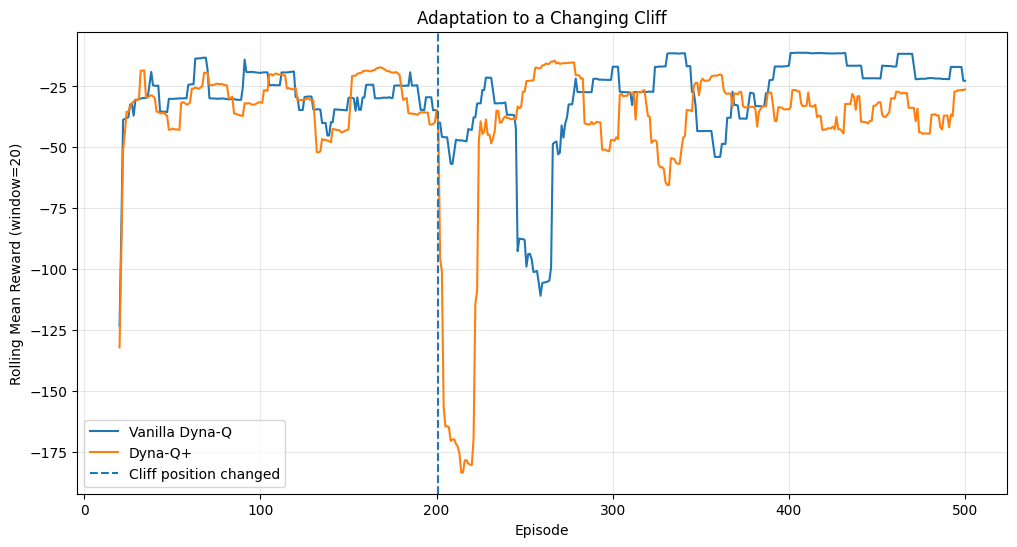

In [33]:
window = 20

standard_smooth = np.convolve(
    R_standard_ns,
    np.ones(window) / window,
    mode='valid'
)

plus_smooth = np.convolve(
    R_plus,
    np.ones(window) / window,
    mode='valid'
)

episodes = np.arange(window, n_bonus_episodes + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    episodes,
    standard_smooth,
    label='Vanilla Dyna-Q'
)

plt.plot(
    episodes,
    plus_smooth,
    label='Dyna-Q+'
)

plt.axvline(
    change_episode + 1,
    linestyle='--',
    label='Cliff position changed'
)

plt.xlabel('Episode')
plt.ylabel(f'Rolling Mean Reward (window={window})')
plt.title('Adaptation to a Changing Cliff')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
def print_adaptation_statistics(name, rewards, change_episode=200):
    before_change = np.mean(
        rewards[change_episode - 50:change_episode]
    )

    immediately_after = np.mean(
        rewards[change_episode:change_episode + 50]
    )

    final_performance = np.mean(rewards[-50:])

    print(name)
    print(f'  Before change:     {before_change:.2f}')
    print(f'  First 50 after:    {immediately_after:.2f}')
    print(f'  Final 50 episodes: {final_performance:.2f}')


print_adaptation_statistics(
    'Vanilla Dyna-Q',
    R_standard_ns,
    change_episode
)

print_adaptation_statistics(
    'Dyna-Q+',
    R_plus,
    change_episode
)

Vanilla Dyna-Q
  Before change:     -30.60
  First 50 after:    -57.66
  Final 50 episodes: -20.14
Dyna-Q+
  Before change:     -27.42
  First 50 after:    -90.86
  Final 50 episodes: -33.38


In [35]:
env_standard_vis = NonStationaryCliffWalkingEnv(
    change_episode=0,
    render_mode='rgb_array'
)

create_policy_eval_video(
    env_standard_vis,
    greedy_policy,
    'vanilla_after_change',
    Q=q_standard_ns,
    max_steps=50
)

In [36]:
env_plus_vis = NonStationaryCliffWalkingEnv(
    change_episode=0,
    render_mode='rgb_array'
)

create_policy_eval_video(
    env_plus_vis,
    greedy_policy,
    'dynaq_plus_after_change',
    Q=q_plus,
    max_steps=50
)

### Discussion

Before the cliff changed, Dyna-Q+ performed slightly better than vanilla Dyna-Q: $-27.42$ versus $-30.60$.

After the change, however, Dyna-Q+ adapted more slowly. Its average reward during the first 50 new episodes was $-90.86$, compared with $-57.66$ for vanilla Dyna-Q. Its final performance was also worse: $-33.38$ versus $-20.14$.

Therefore, Dyna-Q+ did not show an advantage in this experiment. A likely reason is that $\kappa=0.05$ produced too much exploration and kept old model transitions overly attractive after the environment changed. A smaller $\kappa$ and experiments over several random seeds may give more reliable results.
